Static trial eyetracking

Loads static Orientation Imagery runs (task name without `Dynamic`) for participants `S01` to `S20`, preprocesses eyetracking, and summarizes average eye position over the course of the experiment by condition.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

import eyetracking_preprocessing

BIDS_ROOT = Path('/Users/sm6511/Desktop/NIH_Experiment/Bids')
SUBJECTS = [f'S{i:02d}' for i in range(1, 21)]
SFREQ = 1200
EVENT_IDS = list(range(1, 18))
TMIN, TMAX = -.2, .4
ANALYSIS_WINDOW = (0, .4)
N_PROGRESS_BINS = 10

print('BIDS root:', BIDS_ROOT)
print('Subjects:', SUBJECTS)

BIDS root: /Users/sm6511/Desktop/NIH_Experiment/Bids
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20']


In [6]:
def get_static_ds_paths(bids_root: Path, subj: str):
    meg_dir = bids_root / f'sub-{subj}' / 'ses-1' / 'meg'
    pattern = f'sub-{subj}_ses-1_task-OrientationImagery_run-*_meg.ds'
    return sorted(meg_dir.glob(pattern))


def events_file_from_ds(ds_path: Path):
    base = ds_path.name.replace('_meg.ds', '')
    return ds_path.parent / f'{base}_events.tsv'


def parse_condition(trial_type):
    if pd.isna(trial_type):
        return 'unknown'
    tt = str(trial_type)
    parts = tt.split('/')
    if len(parts) >= 3:
        return parts[2]
    return parts[-1] if parts else 'unknown'


def load_run_epochs(ds_path: Path):
    eyes = eyetracking_preprocessing.process_run(str(ds_path))
    eye_df = eyes[['x_deg', 'y_deg', 'pupil']].copy()

    info = mne.create_info(['x_deg', 'y_deg', 'pupil'], sfreq=SFREQ)
    raw_eye = mne.io.RawArray(eye_df.to_numpy().T, info, first_samp=0)

    raw_meg = mne.io.read_raw_ctf(str(ds_path), preload=False, system_clock='ignore', clean_names=True)
    events, _ = mne.events_from_annotations(raw_meg)

    events = events[np.isin(events[:, 2], EVENT_IDS)]

    events_tsv = events_file_from_ds(ds_path)
    metadata = None
    if events_tsv.exists():
        metadata = pd.read_csv(events_tsv, sep='\t')
        if len(metadata) >= len(events):
            metadata = metadata.iloc[:len(events)].reset_index(drop=True)
        else:
            # Keep alignment safe if metadata has fewer rows than usable events.
            events = events[:len(metadata)]
            metadata = metadata.reset_index(drop=True)
        if 'trial_type' in metadata.columns:
            metadata['condition'] = metadata['trial_type'].apply(parse_condition)
        else:
            metadata['condition'] = 'unknown'

    epochs = mne.Epochs(
        raw_eye,
        events,
        event_id=EVENT_IDS,
        tmin=TMIN,
        tmax=TMAX,
        baseline=(TMIN, 0.0),
        metadata=metadata,
        preload=True,
        reject_by_annotation=False,
    )
    return epochs

In [ ]:
rows = []
missing_subjects = []

for subj in SUBJECTS:
    ds_paths = get_static_ds_paths(BIDS_ROOT, subj)
    if len(ds_paths) == 0:
        missing_subjects.append(subj)
        continue

    subj_trial_counter = 0
    for run_idx, ds_path in enumerate(ds_paths, start=1):
        try:
            epochs = load_run_epochs(ds_path)
        except Exception as exc:
            print(f'[WARN] {subj} run-{run_idx:02d} failed: {exc}')
            continue

        analysis_epochs = epochs.copy().crop(*ANALYSIS_WINDOW)
        x_vals = np.nanmean(analysis_epochs.get_data(picks='x_deg'), axis=(1, 2))
        y_vals = np.nanmean(analysis_epochs.get_data(picks='y_deg'), axis=(1, 2))

        if epochs.metadata is not None and 'condition' in epochs.metadata.columns:
            conds = epochs.metadata['condition'].astype(str).to_list()
        else:
            conds = ['unknown'] * len(x_vals)

        for i in range(len(x_vals)):
            rows.append(
                {
                    'subject': subj,
                    'run': run_idx,
                    'trial_index_within_subject': subj_trial_counter + i,
                    'condition': conds[i],
                    'x_mean_deg': x_vals[i],
                    'y_mean_deg': y_vals[i],
                }
            )

        subj_trial_counter += len(x_vals)

summary_df = pd.DataFrame(rows)
print('Loaded trials:', len(summary_df))
print('Subjects with no static runs found:', missing_subjects)
summary_df.head()

loading file /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImagery_run-01_meg.ds
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImagery_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.75   71.65    0.00 mm <->    3.75   71.65   -0.00 mm (orig :  -41.24   60.00 -249.05 mm) diff =    0.000 mm
      -3.75  -71.65    0.00 mm <->   -3.75  -71.65   -0.00 mm (orig :   56.29  -45.24 -250.55 mm) diff =    0.000 mm
      89.55    0.00    0.00 mm <->   89.55   -0.00    0.00 mm (orig :   68.70   70.21 -231.63 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_se

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:19: RuntimeWarning: Mean of empty slice
  x_vals = np.nanmean(analysis_epochs.get_data(picks='x_deg'), axis=(1, 2))
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:20: RuntimeWarning: Mean of empty slice
  y_vals = np.nanmean(analysis_epochs.get_data(picks='y_deg'), axis=(1, 2))
/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.0003798119723752628
removed 3176 samples
removed 541 samples
removed 104 samples
removed 88 samples
removed 92 samples
removed 88 samples
Creating RawArray with float64 data, n_channels=3, n_times=312280
    Range : 0 ... 312279 =      0.000 ...   260.233 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImagery_run-02_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.96   71.54    0.00 mm <->    3.96   71.54   -0.00 mm (orig :  -40.87   60.11 -249.20 mm) diff =    0.000 mm
      -3.96  -71.54    0.00 mm <->   -3.96  -71.54   -0.00 mm (orig :   56.34  -45.17 -250.62 mm) diff =    0.000 mm
      90.17    0.00    0.00 mm <->   90.17    0.00    0.00 mm (orig :   68.96   70.52 -229.74 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordina

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:19: RuntimeWarning: Mean of empty slice
  x_vals = np.nanmean(analysis_epochs.get_data(picks='x_deg'), axis=(1, 2))
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:20: RuntimeWarning: Mean of empty slice
  y_vals = np.nanmean(analysis_epochs.get_data(picks='y_deg'), axis=(1, 2))
/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.0003367513418158428
removed 2428 samples
removed 427 samples
removed 4 samples
removed 112 samples
removed 111 samples
Creating RawArray with float64 data, n_channels=3, n_times=311720
    Range : 0 ... 311719 =      0.000 ...   259.766 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImagery_run-03_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       4.08   71.51    0.00 mm <->    4.08   71.51    0.00 mm (orig :  -40.90   60.09 -250.08 mm) diff =    0.000 mm
      -4.08  -71.51    0.00 mm <->   -4.08  -71.51    0.00 mm (orig :   56.33  -45.11 -250.68 mm) diff =    0.000 mm
      89.88    0.00    0.00 mm <->   89.88   -0.00    0.00 mm (orig :   68.60   70.63 -230.76 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 

...

threshold: 0.10174911563102655
removed 985 samples
removed 349 samples
removed 0 samples
removed 1122 samples
removed 813 samples
removed 728 samples
Creating RawArray with float64 data, n_channels=3, n_times=304360
    Range : 0 ... 304359 =      0.000 ...   253.632 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S12/ses-1/meg/sub-S12_ses-1_task-OrientationImagery_run-03_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       2.60   73.70    0.00 mm <->    2.60   73.70    0.00 mm (orig :  -36.47   63.44 -262.65 mm) diff =    0.000 mm
      -2.60  -73.70    0.00 mm <->   -2.60  -73.70    0.00 mm (orig :   59.34  -48.66 -265.00 mm) diff =    0.000 mm
      89.83    0.00    0.00 mm <->   89.83   -0.00    0.00 mm (orig :   77.61   68.13 -264.54 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinat

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:19: RuntimeWarning: Mean of empty slice
  x_vals = np.nanmean(analysis_epochs.get_data(picks='x_deg'), axis=(1, 2))
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:20: RuntimeWarning: Mean of empty slice
  y_vals = np.nanmean(analysis_epochs.get_data(picks='y_deg'), axis=(1, 2))


threshold: 0.10351084917545388
removed 1299 samples
removed 89 samples
removed 41 samples
removed 588 samples
removed 593 samples
removed 623 samples
Creating RawArray with float64 data, n_channels=3, n_times=301880
    Range : 0 ... 301879 =      0.000 ...   251.566 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S12/ses-1/meg/sub-S12_ses-1_task-OrientationImagery_run-04_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       2.82   72.86    0.00 mm <->    2.82   72.86   -0.00 mm (orig :  -36.95   64.39 -265.45 mm) diff =    0.000 mm
      -2.82  -72.86    0.00 mm <->   -2.82  -72.86   -0.00 mm (orig :   56.51  -47.49 -269.42 mm) diff =    0.000 mm
      90.13    0.00    0.00 mm <->   90.13   -0.00    0.00 mm (orig :   76.67   68.85 -266.89 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinat

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:19: RuntimeWarning: Mean of empty slice
  x_vals = np.nanmean(analysis_epochs.get_data(picks='x_deg'), axis=(1, 2))
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_21109/2935429989.py:20: RuntimeWarning: Mean of empty slice
  y_vals = np.nanmean(analysis_epochs.get_data(picks='y_deg'), axis=(1, 2))


threshold: 0.11096856370967428
removed 1019 samples
removed 137 samples
removed 331 samples
removed 931 samples
removed 671 samples
removed 812 samples
Creating RawArray with float64 data, n_channels=3, n_times=329200
    Range : 0 ... 329199 =      0.000 ...   274.332 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S13/ses-1/meg/sub-S13_ses-1_task-OrientationImagery_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
      -2.17   70.47    0.00 mm <->   -2.17   70.47   -0.00 mm (orig :  -47.22   50.98 -244.90 mm) diff =    0.000 mm
       2.17  -70.47    0.00 mm <->    2.17  -70.47   -0.00 mm (orig :   60.19  -40.32 -241.38 mm) diff =    0.000 mm
      83.97    0.00    0.00 mm <->   83.97   -0.00    0.00 mm (orig :   60.12   65.35 -219.25 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordin

In [1]:
if summary_df.empty:
    raise RuntimeError('No data loaded. Check BIDS_ROOT and file naming.')

def add_progress_bin(df, n_bins=10):
    out = df.copy()
    out['progress'] = out.groupby('subject')['trial_index_within_subject'].transform(
        lambda x: x / max(len(x) - 1, 1)
    )
    out['progress_bin'] = pd.cut(
        out['progress'],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True,
        labels=[f'{int(100*i/n_bins)}-{int(100*(i+1)/n_bins)}%' for i in range(n_bins)],
    )
    return out

plot_df = add_progress_bin(summary_df, n_bins=N_PROGRESS_BINS)

agg = (
    plot_df.groupby(['condition', 'progress_bin'], observed=True)[['x_mean_deg', 'y_mean_deg']]
    .mean()
    .reset_index()
)

bin_order = [f'{int(100*i/N_PROGRESS_BINS)}-{int(100*(i+1)/N_PROGRESS_BINS)}%' for i in range(N_PROGRESS_BINS)]
x_axis = np.arange(N_PROGRESS_BINS)

NameError: name 'summary_df' is not defined

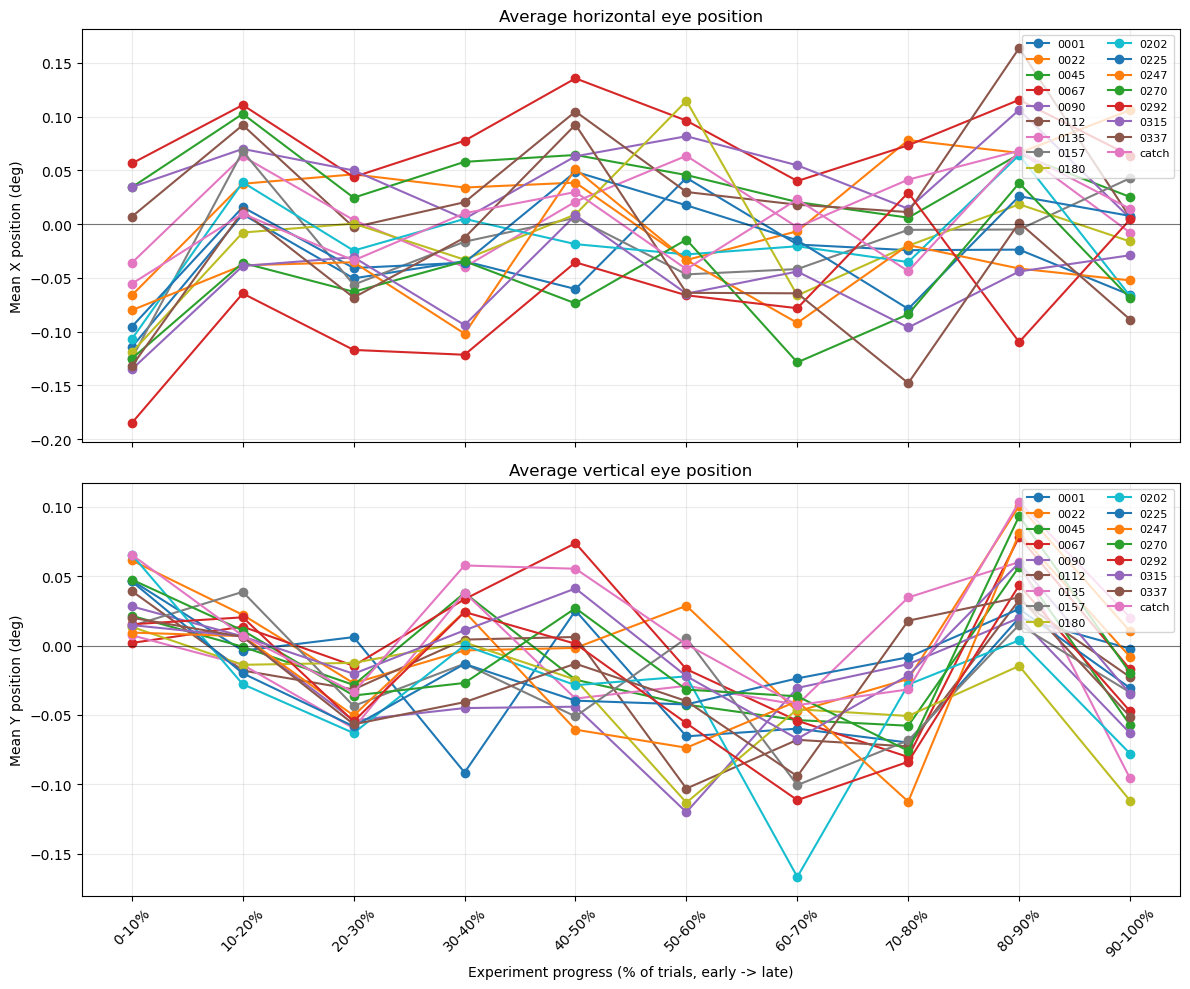

In [9]:
conditions = sorted(agg['condition'].dropna().unique())

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for cond in conditions:
    cur = agg[agg['condition'] == cond].set_index('progress_bin').reindex(bin_order)
    axes[0].plot(x_axis, cur['x_mean_deg'].to_numpy(), marker='o', label=cond)
    axes[1].plot(x_axis, cur['y_mean_deg'].to_numpy(), marker='o', label=cond)

axes[0].set_ylabel('Mean X position (deg)')
axes[0].set_title('Average horizontal eye position')
axes[0].axhline(0, color='k', linewidth=0.8, alpha=0.5)

axes[1].set_ylabel('Mean Y position (deg)')
axes[1].set_title('Average vertical eye position')
axes[1].set_xlabel('Experiment progress (% of trials, early -> late)')
axes[1].axhline(0, color='k', linewidth=0.8, alpha=0.5)

axes[1].set_xticks(x_axis)
axes[1].set_xticklabels(bin_order, rotation=45)

for ax in axes:
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

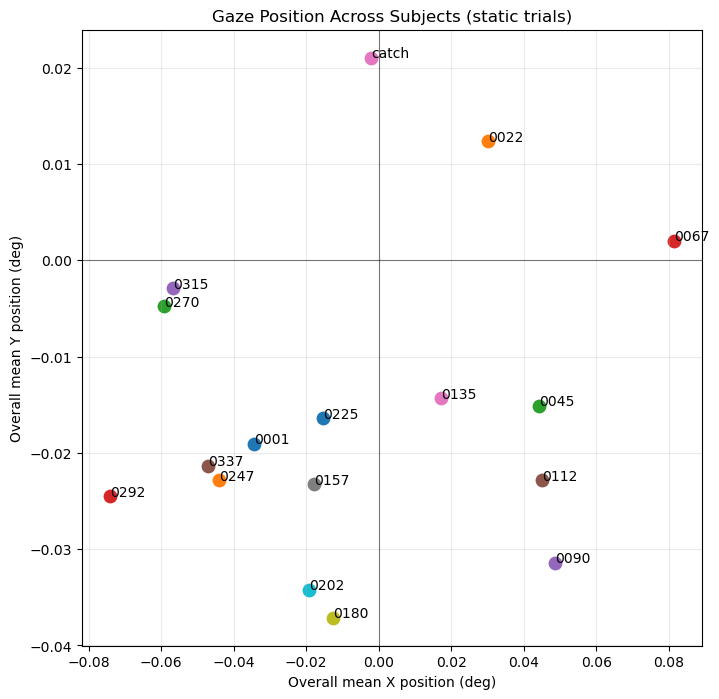

,condition,x_mean_deg,y_mean_deg
0,0001,-0.034415,-0.019052
1,0022,0.030201,0.012327
2,0045,0.044246,-0.015091
3,0067,0.081344,0.002012
4,0090,0.048583,-0.031398
5,0112,0.044940,-0.022830
6,0135,0.017066,-0.014329
7,0157,-0.017899,-0.023245
8,0180,-0.012652,-0.037120
9,0202,-0.019339,-0.034194


In [7]:
overall = summary_df.groupby('condition')[['x_mean_deg', 'y_mean_deg']].mean().reset_index()

plt.figure(figsize=(8, 8))
for _, row in overall.iterrows():
    plt.scatter(row['x_mean_deg'], row['y_mean_deg'], s=80)
    plt.text(row['x_mean_deg'], row['y_mean_deg'], str(row['condition']))

plt.axhline(0, color='k', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='k', linewidth=0.8, alpha=0.5)
plt.xlabel('Overall mean X position (deg)')
plt.ylabel('Overall mean Y position (deg)')
plt.title('Gaze Position Across Subjects (static trials)')
plt.grid(alpha=0.25)
plt.show()

overall